## 1_4 dino

omen@phoenix:/scratch/codepk37/dino$ python visualize_attention.py      --pretrained_weights weights/dino_vitbase8_pretrain.pth   --image_path images/kangaroo.jpg   --output_dir outputs/akngaroo   --image_size 960 960   --threshold 0.6


Images :[text](1.4/1_4_images)

Attention maps: [text](1.4/1_4_outputs)

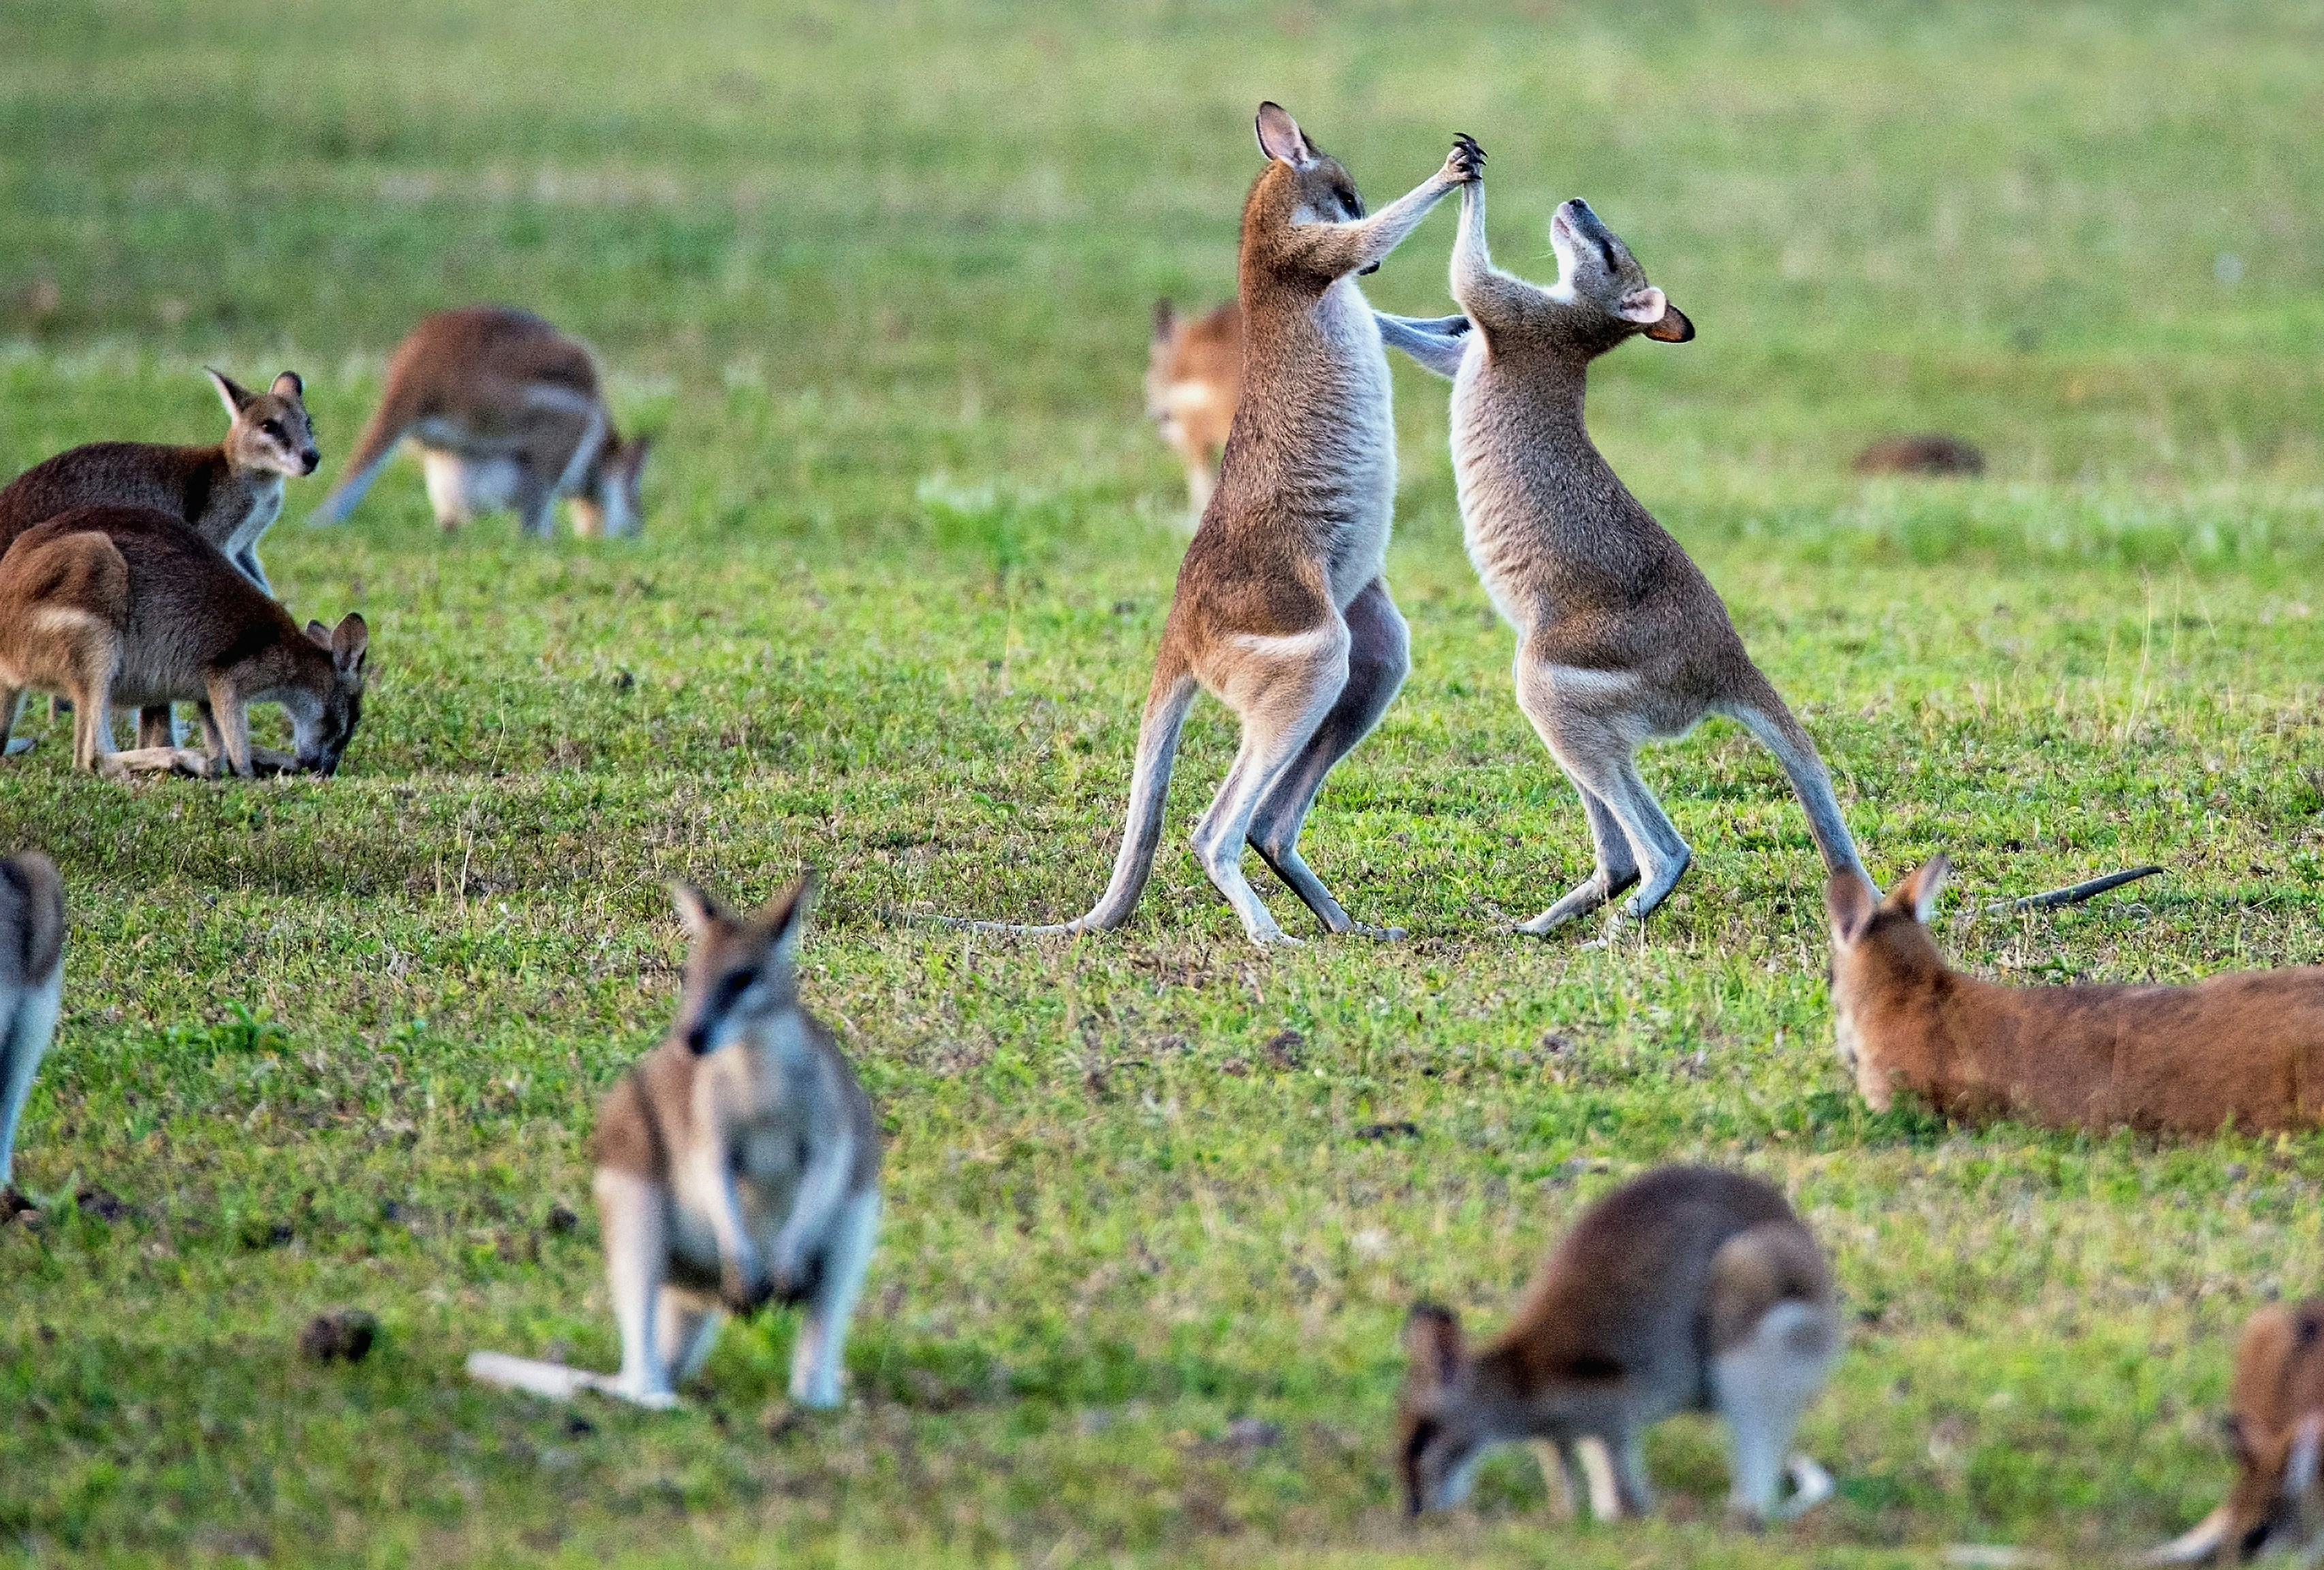

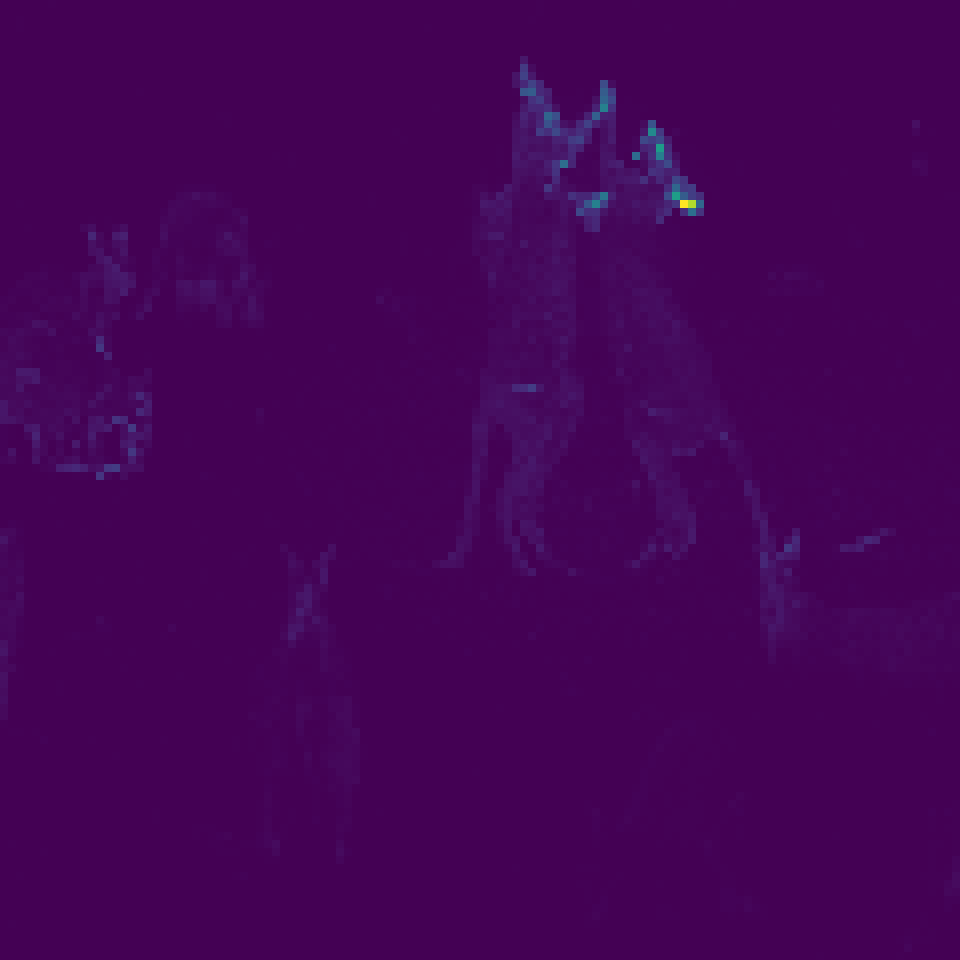
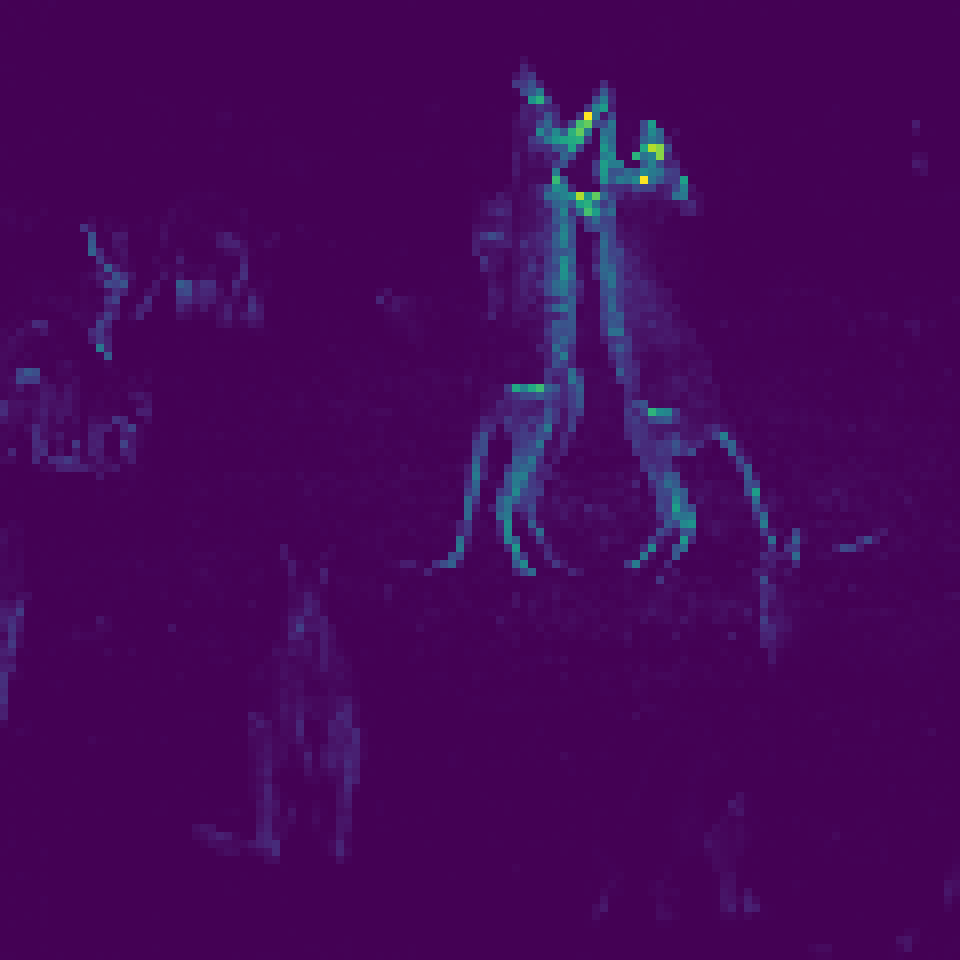
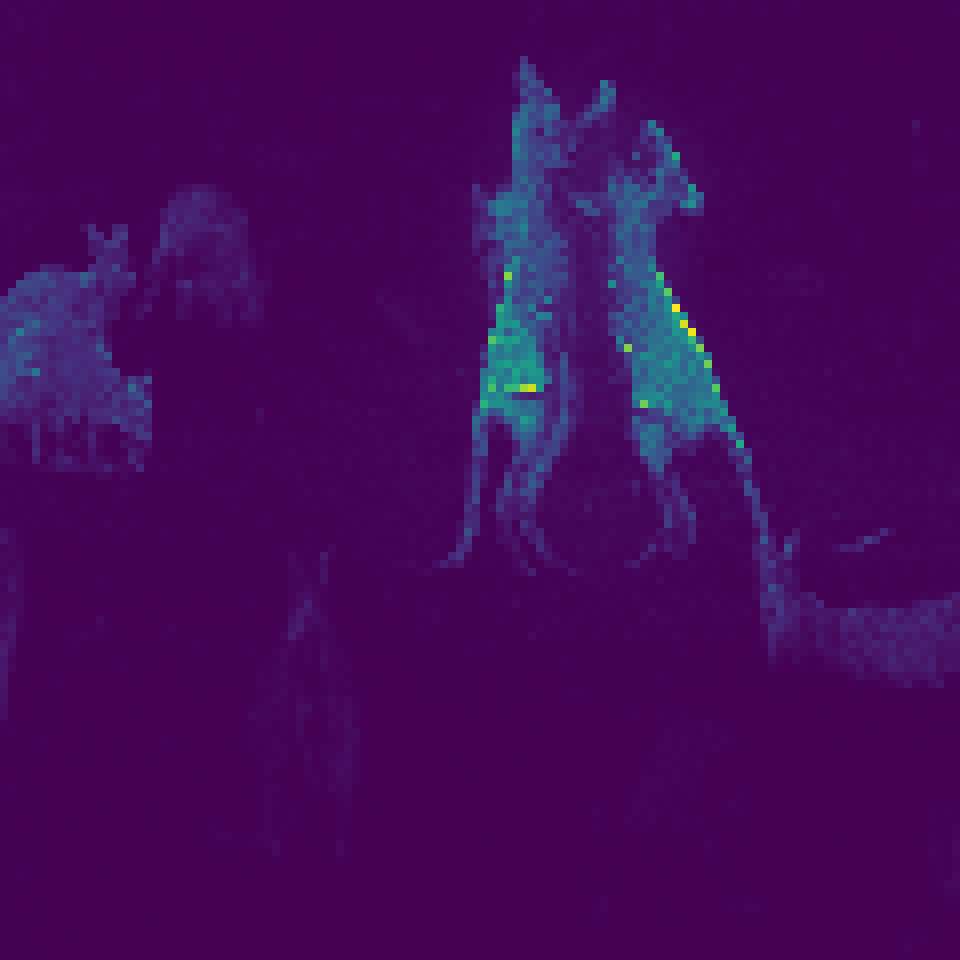
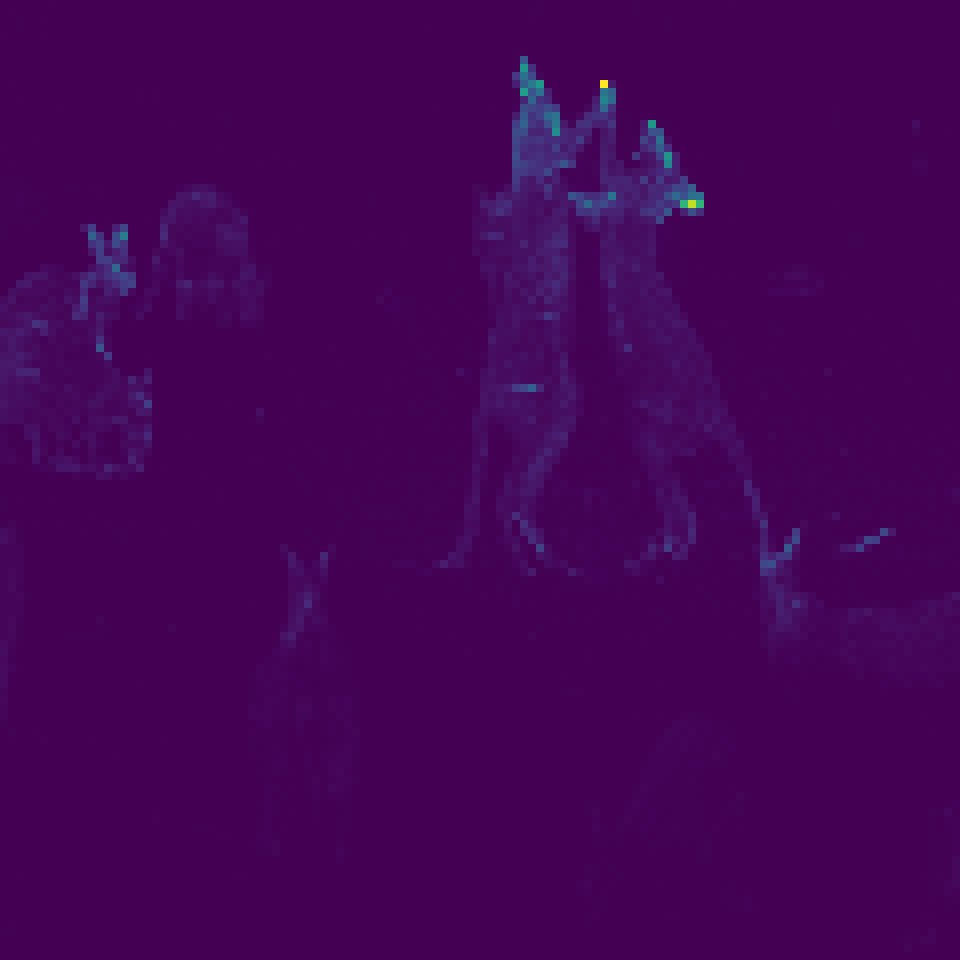
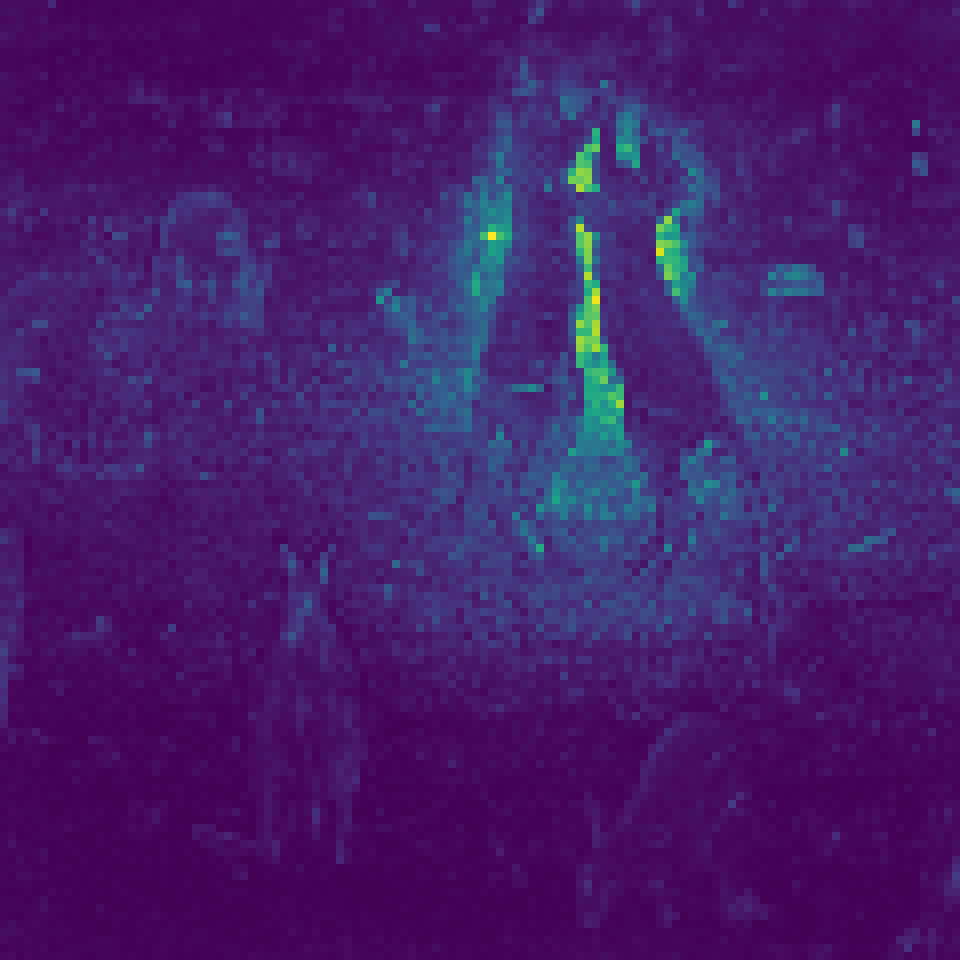
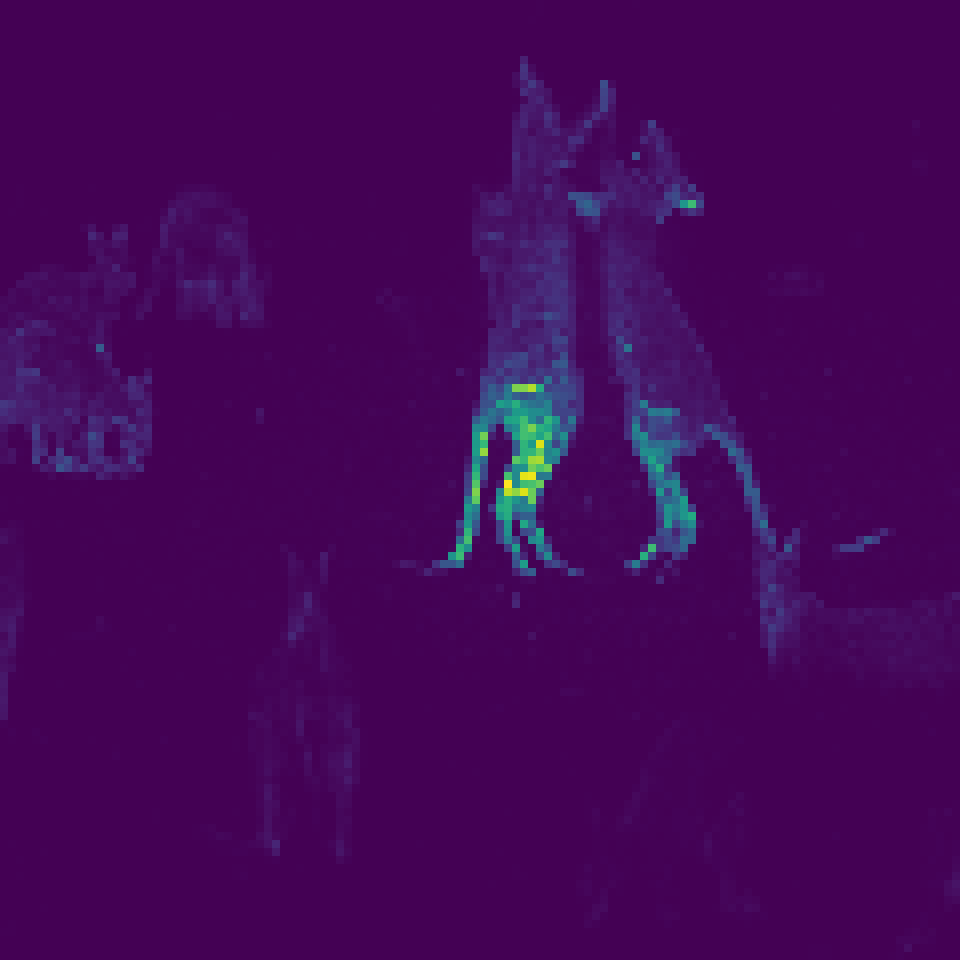

## 2)ViT CIFAR-10 Attention Maps:

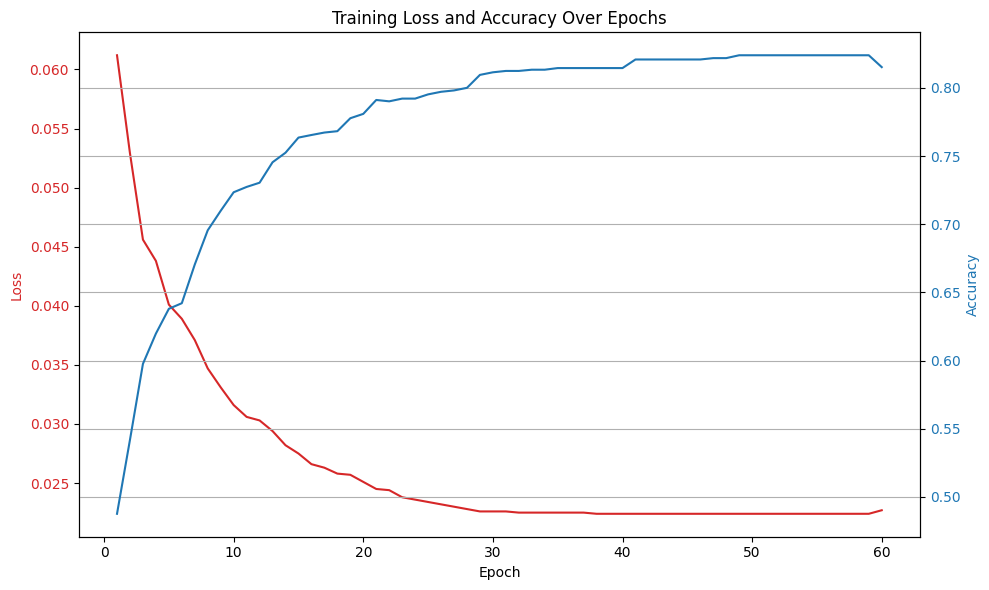

In [5]:
# Vision Transformer (ViT) – Full Implementation for CIFAR-10
# Based on the paper: "An Image is Worth 16x16 Words"
# Covers: Training, Positional Embeddings, Attention Maps, Rollout, Visualization

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os

# ----------------------------------------
# Patch Embedding
# ----------------------------------------
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, emb_dim=192):
        super().__init__()
        self.n_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, emb_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)  # [B, N, D]
        return x

# ----------------------------------------
# Attention
# ----------------------------------------
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, dim, heads=8):
        super().__init__()
        self.heads = heads
        self.head_dim = dim // heads
        self.scale = self.head_dim ** -0.5
        self.qkv = nn.Linear(dim, dim * 3)
        self.out = nn.Linear(dim, dim)

    def forward(self, x):
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        self.attn_map = attn.detach()  # store for visualization
        out = (attn @ v).transpose(1, 2).reshape(B, N, D)
        return self.out(out)

# ----------------------------------------
# Transformer Block
# ----------------------------------------
class TransformerEncoderBlock(nn.Module):
    def __init__(self, dim, heads, mlp_dim):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = MultiHeadSelfAttention(dim, heads)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, mlp_dim),
            nn.GELU(),
            nn.Linear(mlp_dim, dim),
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

# ----------------------------------------
# Sinusoidal Positional Embedding
# ----------------------------------------
def get_sinusoid_encoding(n_position, d_hid):
    def get_angle(pos, i):
        return pos / pow(10000, (2 * (i // 2)) / d_hid)
    sinusoid_table = np.array([[get_angle(pos, i) for i in range(d_hid)] for pos in range(n_position)])
    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])
    return torch.tensor(sinusoid_table, dtype=torch.float).unsqueeze(0)

# ----------------------------------------
# Vision Transformer
# ----------------------------------------
class VisionTransformer(nn.Module):
    def __init__(self, img_size=32, patch_size=4, emb_dim=192, depth=6, heads=8, mlp_dim=1024, n_classes=10):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, emb_dim=emb_dim)
        self.num_patches = (img_size // patch_size) ** 2
        self.cls_token = nn.Parameter(torch.randn(1, 1, emb_dim))
        self.pos_embed = get_sinusoid_encoding(self.num_patches + 1, emb_dim)
        self.encoder = nn.Sequential(*[TransformerEncoderBlock(emb_dim, heads, mlp_dim) for _ in range(depth)])
        self.norm = nn.LayerNorm(emb_dim)
        self.head = nn.Linear(emb_dim, n_classes)

    def forward(self, x):
        x = self.patch_embed(x)
        B, N, _ = x.shape
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed[:, :x.size(1)].to(x.device)
        for block in self.encoder:
            x = block(x)
        x = self.norm(x[:, 0])
        return self.head(x)

# ----------------------------------------
# Training and Evaluation
# ----------------------------------------
def train(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

def evaluate(model, dataloader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

# ----------------------------------------
# Main Training Script (with checkpoint)
# ----------------------------------------
def train_and_save():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(32, padding=2),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
    ])

    trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
    trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
    testloader = DataLoader(testset, batch_size=100, shuffle=False, num_workers=2)

    model = VisionTransformer().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=4, verbose=True) #REDUCE LR by factor of 0.5 if val accuracy does not improve for 4 epochs dosent improve for 3 epochs 


    best_acc = 0
    patience = 7
    trigger_times = 0
    max_epochs = 0

    for epoch in range(max_epochs):
        loss = train(model, trainloader, optimizer, criterion, device)
        acc = evaluate(model, testloader, device)
        scheduler.step(acc)

        print(f"Epoch {epoch+1}/{max_epochs}, Loss: {loss:.4f}, Accuracy: {acc:.4f}")

        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), "vit_best_sinusoidal.pth")
            print("Model saved.")
            trigger_times = 0
        else:
            trigger_times += 1
            print(f"No improvement. Early stopping trigger count: {trigger_times}/{patience}")

        if trigger_times >= patience:
            print("Early stopping triggered.")
            break

    print("Training completed. Best accuracy:", best_acc)

# ----------------------------------------
# Start Training
# ----------------------------------------
# if __name__ == '__main__': saved already 
#     train_and_save()
# No improvement. Early stopping trigger count: 5/7
# Training completed. Best accuracy: 0.8257
import matplotlib.pyplot as plt
# Extracted values from the logs
epochs = list(range(1, 61))
loss_values = [
    0.0612, 0.0529, 0.0456, 0.0438, 0.0401, 0.0389, 0.0371, 0.0347, 0.0331, 0.0316,
    0.0306, 0.0303, 0.0294, 0.0282, 0.0275, 0.0266, 0.0263, 0.0258, 0.0257, 0.0251,
    0.0245, 0.0244, 0.0238, 0.0236, 0.0234, 0.0232, 0.0230, 0.0228, 0.0226, 0.0226,
    0.0226, 0.0225, 0.0225, 0.0225, 0.0225, 0.0225, 0.0225, 0.0224, 0.0224, 0.0224,
    0.0224, 0.0224, 0.0224, 0.0224, 0.0224, 0.0224, 0.0224, 0.0224, 0.0224, 0.0224,
    0.0224, 0.0224, 0.0224, 0.0224, 0.0224, 0.0224, 0.0224, 0.0224, 0.0224, 0.0227
]

accuracy_values = [
    0.4876, 0.5419, 0.5976, 0.6198, 0.6380, 0.6421, 0.6705, 0.6956, 0.7099, 0.7235,
    0.7274, 0.7305, 0.7455, 0.7525, 0.7636, 0.7655, 0.7673, 0.7683, 0.7778, 0.7810,
    0.7912, 0.7902, 0.7922, 0.7922, 0.7953, 0.7972, 0.7982, 0.8001, 0.8096, 0.8115,
    0.8125, 0.8125, 0.8134, 0.8134, 0.8146, 0.8146, 0.8146, 0.8146, 0.8146, 0.8146,
    0.8209, 0.8209, 0.8209, 0.8209, 0.8209, 0.8209, 0.8219, 0.8219, 0.8240, 0.8240,
    0.8240, 0.8240, 0.8240, 0.8240, 0.8240, 0.8240, 0.8240, 0.8240, 0.8240, 0.8153
]

# Create the plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot loss
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='tab:red')
ax1.plot(epochs, loss_values, color='tab:red', label='Loss')
ax1.tick_params(axis='y', labelcolor='tab:red')

# Create another axis for accuracy
ax2 = ax1.twinx()
ax2.set_ylabel('Accuracy', color='tab:blue')
ax2.plot(epochs, accuracy_values, color='tab:blue', label='Accuracy')
ax2.tick_params(axis='y', labelcolor='tab:blue')

# Title and layout
plt.title('Training Loss and Accuracy Over Epochs')
fig.tight_layout()

plt.grid(True)
plt.show()



In [7]:
# ----------------------------------------
# Attention Map Visualization
# ----------------------------------------
import torchvision.utils as vutils

def extract_attention_maps(model, image_tensor, device):
    model.eval()
    image_tensor = image_tensor.unsqueeze(0).to(device)
    attention_weights = []

    def hook_fn(module, input, output):
        if hasattr(module, 'attn_map'):
            attention_weights.append(module.attn_map.detach().cpu())

    hooks = [blk.attn.register_forward_hook(hook_fn) for blk in model.encoder]
    _ = model(image_tensor)
    for h in hooks:
        h.remove()
    return attention_weights


def show_attention_maps(model_path, img_indices=[1, 4], save_dir='attention_maps'):
    os.makedirs(save_dir, exist_ok=True)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
    ])
    dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
    raw_transform = transforms.Compose([transforms.ToTensor()])
    raw_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=raw_transform)

    model = VisionTransformer().to(device)
    model.load_state_dict(torch.load(model_path))

    for idx in img_indices:
        image, label = dataset[idx]
        raw_image, _ = raw_dataset[idx]

        # Save the original image
        plt.imshow(np.transpose(raw_image.numpy(), (1, 2, 0)))
        plt.title(f"Original CIFAR-10 Image {idx}")
        plt.axis('off')
        plt.savefig(f"{save_dir}/img{idx}_original.png")
        plt.close()

        attn_weights = extract_attention_maps(model, image, device)
        B, H, N, _ = attn_weights[-1].shape  # use last layer
        num_patches = N - 1
        grid_size = int(np.sqrt(num_patches))

        for h in range(H):
            attn_map = attn_weights[-1][0, h, 0, 1:].reshape(grid_size, grid_size)
            plt.imshow(attn_map, cmap='viridis')
            plt.colorbar()
            plt.title(f"Image {idx} - Last Layer Head {h+1}")
            plt.axis('off')
            plt.savefig(f"{save_dir}/img{idx}_layerLast_head{h+1}.png")
            plt.close()

        avg_attn = attn_weights[-1][0, :, 0, 1:].mean(0).reshape(grid_size, grid_size)
        plt.imshow(avg_attn, cmap='inferno')
        plt.title(f"Image {idx} - Aggregated Last Layer Attention")
        plt.colorbar()
        plt.axis('off')
        plt.savefig(f"{save_dir}/img{idx}_layerLast_agg.png")
        plt.close()

        # All layers
        for l, layer_attn in enumerate(attn_weights):
            avg_layer_attn = layer_attn[0, :, 0, 1:].mean(0).reshape(grid_size, grid_size)
            plt.imshow(avg_layer_attn, cmap='magma')
            plt.title(f"Image {idx} - Layer {l+1} Avg Attention")
            plt.colorbar()
            plt.axis('off')
            plt.savefig(f"{save_dir}/img{idx}_layer{l+1}_agg.png")
            plt.close()

# Example usage to generate maps for 3 CIFAR-10 test images
if __name__ == '__main__':
    show_attention_maps(model_path='vit_best_sinusoidal.pth')

Files already downloaded and verified
Files already downloaded and verified


/tmp/ipykernel_8209/833495428.py:35: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


## Output attention Maps at [images](attention_maps)

## 3. Attention Rollout:

In [9]:
# 3. Attention Rollout:


def compute_attention_rollout(attention_weights):
    rollout = None
    for layer_attn in attention_weights:
        attn = layer_attn[0]  # [heads, N, N]
        attn_mean = attn.mean(0)  # [N, N]
        attn_augmented = attn_mean + torch.eye(attn_mean.size(0))  # add residual connection
        attn_augmented /= attn_augmented.sum(dim=-1, keepdim=True)  # re-normalize
        if rollout is None:
            rollout = attn_augmented
        else:
            rollout = attn_augmented @ rollout  # recursive rollout
    return rollout


def visualize_attention_rollout(model_path='vit_best_sinusoidal.pth', img_indices=[0, 1, 2], save_dir='attention_rollout'):
    os.makedirs(save_dir, exist_ok=True)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
    ])
    dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
    raw_transform = transforms.Compose([transforms.ToTensor()])
    raw_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=raw_transform)

    model = VisionTransformer().to(device)
    model.load_state_dict(torch.load(model_path))

    for idx in img_indices:
        image, _ = dataset[idx]
        raw_image, _ = raw_dataset[idx]

        # Save the original image again for this section
        plt.imshow(np.transpose(raw_image.numpy(), (1, 2, 0)))
        plt.title(f"Rollout: Original Image {idx}")
        plt.axis('off')
        plt.savefig(f"{save_dir}/img{idx}_original.png")
        plt.close()

        attn_weights = extract_attention_maps(model, image, device)
        rollout_map = compute_attention_rollout(attn_weights)

        grid_size = int(np.sqrt(rollout_map.shape[0] - 1))
        rollout_patch = rollout_map[0, 1:].reshape(grid_size, grid_size)

        plt.imshow(rollout_patch, cmap='hot')
        plt.title(f"Attention Rollout Map - Image {idx}")
        plt.colorbar()
        plt.axis('off')
        plt.savefig(f"{save_dir}/img{idx}_rollout.png")
        plt.close()

# Example usage to generate rollout attention maps
if __name__ == '__main__':
    visualize_attention_rollout(model_path='vit_best_sinusoidal.pth')


Files already downloaded and verified
Files already downloaded and verified


/tmp/ipykernel_8209/197649107.py:31: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


## Attention Rollout output :[images](attention_rollout)

## 4. Positional Embedding Visualization:

/tmp/ipykernel_8209/3318554178.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


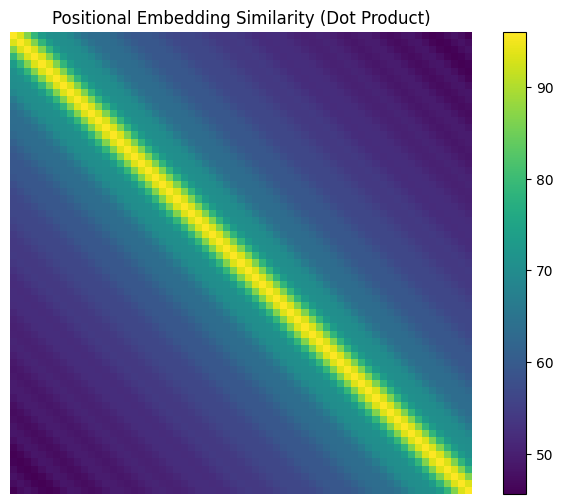

In [10]:

# ----------------------------------------
# Positional Embedding Similarity Visualization
# ----------------------------------------
def visualize_positional_embedding_similarity(model_path='vit_best_sinusoidal.pth', save_path='positional_embedding_similarity.png'):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = VisionTransformer().to(device)
    model.load_state_dict(torch.load(model_path))

    pos_embed = model.pos_embed[0]  # shape: [num_patches+1, emb_dim]
    similarity_matrix = torch.matmul(pos_embed, pos_embed.T)  # [N, N] dot product similarity

    plt.figure(figsize=(8, 6))
    plt.imshow(similarity_matrix.cpu().numpy(), cmap='viridis')
    plt.title("Positional Embedding Similarity (Dot Product)")
    plt.colorbar()
    plt.axis('off')
    plt.show()
    # plt.savefig(save_path)
    plt.close()

# Run positional embedding similarity visualization
if __name__ == '__main__':
    visualize_positional_embedding_similarity(model_path='vit_best_sinusoidal.pth')

